# Vision → Geometry → Risk Pipeline Demo

Notebook này bám đúng luồng code hiện tại:

```text
Ảnh → Vision Engine → representative depth → candidate patches
    → seed filtering (`is_seed_consistent`) → connected-region neighbor search
    → greedy farthest-point sampling → final load anchors
    → relative Pseudo-BEV projection for load anchors and person points
    → depth-independent 2D risk assessment → temporal event decision
```

Depth là tương đối, không phải khoảng cách theo mét. Mỗi candidate lưu độ chênh với seed trong `seed_depth_difference` và quyết định seed gate trong `is_seed_consistent`. Connected region không tính lại seed-depth difference; nó chỉ dùng candidate đã qua seed gate rồi áp dụng local-neighbor gate. `risk_engine` chỉ nhận point và rectangle 2D cùng quality metadata; không nhận depth map hoặc depth confidence.

In [1]:
from __future__ import annotations

import sys
from dataclasses import asdict, replace
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import yaml
from matplotlib.patches import Circle, Rectangle

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
PACKAGES_DIR = PROJECT_ROOT / 'backend' / 'packages'
if not PACKAGES_DIR.is_dir():
    raise RuntimeError('Run the notebook from the project root or notebooks directory')
if str(PACKAGES_DIR) not in sys.path:
    sys.path.insert(0, str(PACKAGES_DIR))

from geometry_engine import (
    GeometryFramePipeline,
    build_load_anchor_candidates,
    build_load_zones,
    calculate_depth_normalization_range,
    estimate_person_representative,
    find_connected_candidate_region,
    load_geometry_config,
    load_representative_depth,
    project_load_anchors_to_pseudo_bev,
    project_person_to_pseudo_bev,
    select_farthest_load_anchors,
)
from risk_engine import (
    EventStateMachine,
    MediaFrameContext,
    MediaType,
    PersonObservation,
    Point2D,
    Rectangle2D,
    RiskEvaluator,
    RiskFramePipeline,
    RiskPairInput,
    ZoneGeometry,
    load_risk_policy,
)
from vision_engine import OfflineFramePipeline, build_model_manager
from vision_engine.frame_pipeline import render_detection_preview

print(f'Project root: {PROJECT_ROOT}')

Project root: D:\crane-load-warning


## 1. Input và cấu hình

In [2]:
IMAGE_PATH = PROJECT_ROOT / 'data' / 'samples' / '232.png'
MODELS_CONFIG_PATH = PROJECT_ROOT / 'configs' / 'models.local.yaml'
GEOMETRY_CONFIG_PATH = PROJECT_ROOT / 'configs' / 'geometry.local.yaml'
RISK_POLICY_CONFIG_PATH = PROJECT_ROOT / 'configs' / 'risk-policy.example.yaml'

for path in (
    IMAGE_PATH, MODELS_CONFIG_PATH, GEOMETRY_CONFIG_PATH,
    RISK_POLICY_CONFIG_PATH,
):
    if not path.is_file():
        raise FileNotFoundError(path)

with MODELS_CONFIG_PATH.open('r', encoding='utf-8') as stream:
    models_payload = yaml.safe_load(stream)
if not isinstance(models_payload, dict):
    raise TypeError('models config root must be a YAML mapping')

geometry_config = load_geometry_config(GEOMETRY_CONFIG_PATH)
risk_policy = load_risk_policy(RISK_POLICY_CONFIG_PATH)
LIMIT_FINAL_ANCHORS = True
image_bgr = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise ValueError(f'OpenCV could not decode {IMAGE_PATH}')

print(f'Image: {IMAGE_PATH.name}; shape={image_bgr.shape}')
geometry_config

Image: 232.png; shape=(768, 1376, 3)


GeometryConfig(representative_depth=RepresentativeDepthConfig(person_bottom_fraction=0.1, minimum_valid_pixels=5, load_inner_size_fraction=0.2), load_anchors=LoadAnchorsConfig(patch_size=11, patch_stride=12, seed_depth_tolerance=0.3), connected_region=ConnectedRegionConfig(neighbor_radius=1, local_neighbor_depth_tolerance=0.1), farthest_point_sampling=FarthestPointSamplingConfig(maximum_anchors=16, minimum_distance=0.0), pseudo_bev=PseudoBEVConfig(lateral_scale=1.0, longitudinal_scale=1.0, minimum_depth=1e-06), zones=ZonesConfig(danger=ZoneBufferConfig(lateral_ratio=0.2, longitudinal_ratio=0.2), warning=ZoneBufferConfig(lateral_ratio=0.4, longitudinal_ratio=0.4)))

## 2. Vision Engine

Model được lazy-load ở lần `process()` đầu tiên.

In [3]:
model_manager = build_model_manager(
    models_payload,
    config_dir=MODELS_CONFIG_PATH.parent,
)
vision_pipeline = OfflineFramePipeline(model_manager)
vision_result = vision_pipeline.process(image_bgr, image_path=IMAGE_PATH)
depth_map = vision_result.relative_depth.depth_map
depth_low, depth_high = calculate_depth_normalization_range(
    depth_map,
    lower_percentile=0,
    upper_percentile=100,
)
preview_bgr = render_detection_preview(image_bgr, vision_result.detections)
preview_rgb = cv2.cvtColor(preview_bgr, cv2.COLOR_BGR2RGB)

detection_counts = {}
for detection in vision_result.detections:
    name = detection['class_name']
    detection_counts[name] = detection_counts.get(name, 0) + 1
print('Detections:', detection_counts)
print('Depth metadata:', asdict(vision_result.relative_depth.metadata))

[2026-08-24 11:45:51] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-24 11:45:51] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-24 11:45:51] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


W0824 11:45:53.011000 22924 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
A matching Triton is not available, some optimizations will not be enabled
Traceback (most recent call last):
  File "d:\crane-load-warning\.venv\Lib\site-packages\xformers\__init__.py", line 57, in _is_triton_available
    import triton  # noqa
    ^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'triton'


[INFO ] using MLP layer as FFN


[2026-08-24 11:45:55] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


[INFO ] Processed Images Done taking 0.04081439971923828 seconds. Shape:  torch.Size([1, 3, 280, 504])
[INFO ] Model Forward Pass Done. Time: 0.29169702529907227 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0019397735595703125 seconds
Detections: {'hanging_object': 1, 'hanging_rope': 1, 'person': 2}
Depth metadata: {'height': 768, 'width': 1376, 'dtype': 'float32', 'finite_min': 0.5289946794509888, 'finite_max': 4.579071998596191, 'finite_fraction': 1.0, 'convention': 'relative_depth_not_metric'}


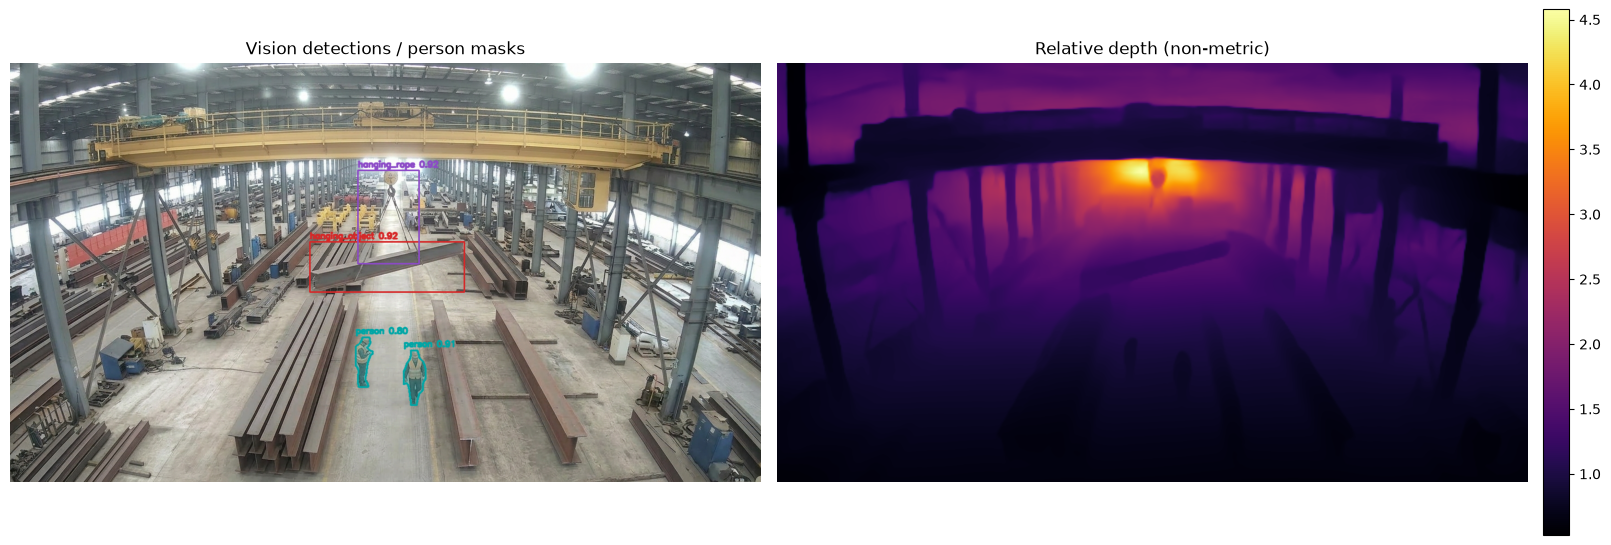

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
axes[0].imshow(preview_rgb)
axes[0].set_title('Vision detections / person masks')
depth_artist = axes[1].imshow(np.ma.masked_invalid(depth_map), cmap='inferno')
axes[1].set_title('Relative depth (non-metric)')
fig.colorbar(depth_artist, ax=axes[1], fraction=0.035, pad=0.02)
for axis in axes:
    axis.axis('off')
plt.show()

## 3. Geometry pipeline

Seed filtering chỉ diễn ra trong `build_load_anchor_candidates()`. Kết quả được lưu bằng `seed_depth_difference` và boolean `is_seed_consistent`. Connected-region chỉ mở rộng qua những candidate đã qua seed gate và đạt local-neighbor tolerance; final anchors sau đó được chọn trực tiếp từ connected region.

In [5]:
person_detections = [
    detection for detection in vision_result.detections
    if detection['class_name'] == 'person'
]
load_detections = [
    detection for detection in vision_result.detections
    if detection['class_name'] == 'hanging_object'
]

person_geometry = []
for index, detection in enumerate(person_detections, start=1):
    representative = estimate_person_representative(
        detection, depth_map, config=geometry_config.representative_depth,
    )
    person_geometry.append({
        'object_id': f'person_{index:02d}',
        'detection': detection,
        'representative': representative,
        'pseudo_bev_point': project_person_to_pseudo_bev(
            representative,
            image_width=image_bgr.shape[1],
            depth_low=depth_low,
            depth_high=depth_high,
            config=geometry_config.pseudo_bev,
        ),
    })

load_geometry = []
for index, detection in enumerate(load_detections, start=1):
    representative = load_representative_depth(
        detection, depth_map, config=geometry_config.representative_depth,
    )
    selection = build_load_anchor_candidates(
        detection,
        depth_map,
        representative_config=geometry_config.representative_depth,
        anchors_config=geometry_config.load_anchors,
    )
    x1, y1, x2, y2 = detection['bbox']
    size_fraction = geometry_config.representative_depth.load_inner_size_fraction
    center_x, center_y = (x1 + x2) / 2.0, (y1 + y2) / 2.0
    half_width = (x2 - x1) * size_fraction / 2.0
    half_height = (y2 - y1) * size_fraction / 2.0
    inner_bbox = (
        center_x - half_width, center_y - half_height,
        center_x + half_width, center_y + half_height,
    )
    connected = find_connected_candidate_region(
        selection.candidates,
        root_bbox=inner_bbox,
        config=geometry_config.connected_region,
    )
    fps_settings = geometry_config.farthest_point_sampling
    if not LIMIT_FINAL_ANCHORS:
        fps_settings = replace(
            fps_settings,
            maximum_anchors=max(1, len(connected)),
            minimum_distance=0.0,
        )
    anchors = select_farthest_load_anchors(
        connected, config=fps_settings,
    )
    pseudo_bev_points = project_load_anchors_to_pseudo_bev(
        anchors,
        image_width=image_bgr.shape[1],
        depth_low=depth_low,
        depth_high=depth_high,
        config=geometry_config.pseudo_bev,
    )
    safety_zones = build_load_zones(
        pseudo_bev_points,
        load_bbox=detection['bbox'],
        image_width=image_bgr.shape[1],
        pseudo_bev_config=geometry_config.pseudo_bev,
        config=geometry_config.zones,
    )
    load_geometry.append({
        'object_id': f'hanging_object_{index:02d}',
        'detection': detection,
        'representative_depth': representative,
        'candidate_selection': selection,
        'inner_bbox': inner_bbox,
        'connected_region': connected,
        'farthest_point_sampling_settings': fps_settings,
        'load_anchors': anchors,
        'pseudo_bev_points': pseudo_bev_points,
        'safety_zones': safety_zones,
    })

production_geometry_result = GeometryFramePipeline(geometry_config).process(
    vision_result.detections, depth_map, frame_id=IMAGE_PATH.stem,
)

### 3.1. Thử nghiệm chiến lược giới hạn anchor

So sánh trên cùng connected region: giới hạn cố định từ YAML, không giới hạn, và adaptive coverage. Phương án adaptive yêu cầu ít nhất 4 anchor khi đủ candidate, dùng coverage radius bằng 8% đường chéo bbox, và giữ safety cap 32 anchor. `maximum_coverage_distance` là khoảng cách lớn nhất từ một connected candidate đến anchor gần nhất; giá trị càng nhỏ thì coverage càng dày.

In [6]:
ANCHOR_COVERAGE_RATIO = 0.08
MINIMUM_COVERAGE_ANCHORS = 4
MAXIMUM_COVERAGE_ANCHORS = 32

def maximum_coverage_distance(candidates, anchors):
    if not candidates:
        return 0.0
    if not anchors:
        return float('inf')
    return float(max(
        min(
            np.hypot(
                candidate.point.x - anchor.point.x,
                candidate.point.y - anchor.point.y,
            )
            for anchor in anchors
        )
        for candidate in candidates
    ))

def select_coverage_anchors(candidates, bbox):
    x1, y1, x2, y2 = bbox
    coverage_radius = float(
        np.hypot(x2 - x1, y2 - y1) * ANCHOR_COVERAGE_RATIO
    )
    base_settings = geometry_config.farthest_point_sampling
    coverage_settings = replace(
        base_settings,
        maximum_anchors=MAXIMUM_COVERAGE_ANCHORS,
        minimum_distance=coverage_radius,
    )
    anchors = select_farthest_load_anchors(
        candidates, config=coverage_settings,
    )
    minimum_anchor_count = min(MINIMUM_COVERAGE_ANCHORS, len(candidates))
    if len(anchors) < minimum_anchor_count:
        minimum_settings = replace(
            base_settings,
            maximum_anchors=minimum_anchor_count,
            minimum_distance=0.0,
        )
        anchors = select_farthest_load_anchors(
            candidates, config=minimum_settings,
        )
    return anchors, coverage_radius

anchor_strategy_rows = []
for item in load_geometry:
    connected = item['connected_region']
    fixed_anchors = select_farthest_load_anchors(
        connected, config=geometry_config.farthest_point_sampling,
    )
    unlimited_settings = replace(
        geometry_config.farthest_point_sampling,
        maximum_anchors=max(1, len(connected)),
        minimum_distance=0.0,
    )
    unlimited_anchors = select_farthest_load_anchors(
        connected, config=unlimited_settings,
    )
    coverage_anchors, coverage_radius = select_coverage_anchors(
        connected, item['detection']['bbox'],
    )
    item['anchor_strategy_results'] = {}
    for strategy, anchors, target_radius in (
        ('fixed_yaml', fixed_anchors, None),
        ('unlimited', unlimited_anchors, None),
        ('adaptive_coverage', coverage_anchors, coverage_radius),
    ):
        maximum_distance = maximum_coverage_distance(connected, anchors)
        item['anchor_strategy_results'][strategy] = {
            'anchors': anchors,
            'coverage_radius': target_radius,
            'maximum_coverage_distance': maximum_distance,
        }
        anchor_strategy_rows.append({
            'load': item['object_id'],
            'strategy': strategy,
            'connected_candidates': len(connected),
            'anchor_count': len(anchors),
            'coverage_radius': (
                None if target_radius is None else round(target_radius, 2)
            ),
            'maximum_coverage_distance': round(maximum_distance, 2),
            'coverage_target_met': (
                None
                if target_radius is None
                else maximum_distance <= target_radius
            ),
        })
anchor_strategy_rows

[{'load': 'hanging_object_01',
  'strategy': 'fixed_yaml',
  'connected_candidates': 189,
  'anchor_count': 16,
  'coverage_radius': None,
  'maximum_coverage_distance': 37.95,
  'coverage_target_met': None},
 {'load': 'hanging_object_01',
  'strategy': 'unlimited',
  'connected_candidates': 189,
  'anchor_count': 189,
  'coverage_radius': None,
  'maximum_coverage_distance': 0.0,
  'coverage_target_met': None},
 {'load': 'hanging_object_01',
  'strategy': 'adaptive_coverage',
  'connected_candidates': 189,
  'anchor_count': 32,
  'coverage_radius': 23.82,
  'maximum_coverage_distance': 24.0,
  'coverage_target_met': False}]

In [7]:
stage_rows = []
for item in load_geometry:
    selection = item['candidate_selection']
    connected_ids = {c.candidate_id for c in item['connected_region']}
    consistent_ids = {c.candidate_id for c in selection.consistent_candidates}
    stage_rows.append({
        'load': item['object_id'],
        'generated_patches': selection.generated_patch_count,
        'valid_depth': len(selection.candidates),
        'seed_consistent': len(consistent_ids),
        'seed_consistent_but_disconnected': len(consistent_ids - connected_ids),
        'connected_region': len(connected_ids),
        'final_anchors': len(item['load_anchors']),
        'seed_depth': selection.seed_depth,
        'seed_source': selection.seed_source,
    })
stage_rows

[{'load': 'hanging_object_01',
  'generated_patches': 192,
  'valid_depth': 192,
  'seed_consistent': 189,
  'seed_consistent_but_disconnected': 0,
  'connected_region': 189,
  'final_anchors': 16,
  'seed_depth': 1.2210395336151123,
  'seed_source': 'inner'}]

## 4. Visualization helpers

In [8]:
COLORS = {
    'person': '#00A6A6', 'load': '#D62728', 'seed': '#FFFF00',
    'accepted': '#00B4FF', 'rejected': '#969696',
    'disconnected': '#D62728', 'selected': '#00C853',
}

def centered_inner_bbox(bbox, size_fraction):
    x1, y1, x2, y2 = bbox
    cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
    half_width = (x2 - x1) * size_fraction / 2.0
    half_height = (y2 - y1) * size_fraction / 2.0
    return cx - half_width, cy - half_height, cx + half_width, cy + half_height

def add_load_regions(axis, detection):
    x1, y1, x2, y2 = detection['bbox']
    axis.add_patch(Rectangle(
        (x1, y1), x2 - x1, y2 - y1, fill=False,
        edgecolor=COLORS['load'], linewidth=2, label='Hanging object',
    ))
    ix1, iy1, ix2, iy2 = centered_inner_bbox(
        detection['bbox'], geometry_config.representative_depth.load_inner_size_fraction,
    )
    axis.add_patch(Rectangle(
        (ix1, iy1), ix2 - ix1, iy2 - iy1, fill=False,
        edgecolor=COLORS['seed'], linewidth=1.5, label='Seed ROI',
    ))

def focus_on_bbox(axis, bbox):
    x1, y1, x2, y2 = bbox
    pad_x, pad_y = (x2 - x1) * 0.08, (y2 - y1) * 0.15
    axis.set_xlim(x1 - pad_x, x2 + pad_x)
    axis.set_ylim(y2 + pad_y, y1 - pad_y)
    axis.axis('off')

def seed_sort_key(candidate):
    difference = candidate.seed_depth_difference
    finite_difference = (
        difference
        if difference is not None and np.isfinite(difference)
        else np.inf
    )
    return (
        finite_difference,
        candidate.point.y,
        candidate.point.x,
        candidate.candidate_id,
    )

### 4.1. Visual comparison of anchor strategies

Chấm xanh nhạt là connected candidates; chấm xanh lá là final anchors; ngôi sao là anchor đầu tiên. Vòng tròn ở phương án adaptive biểu diễn coverage radius quanh từng anchor.

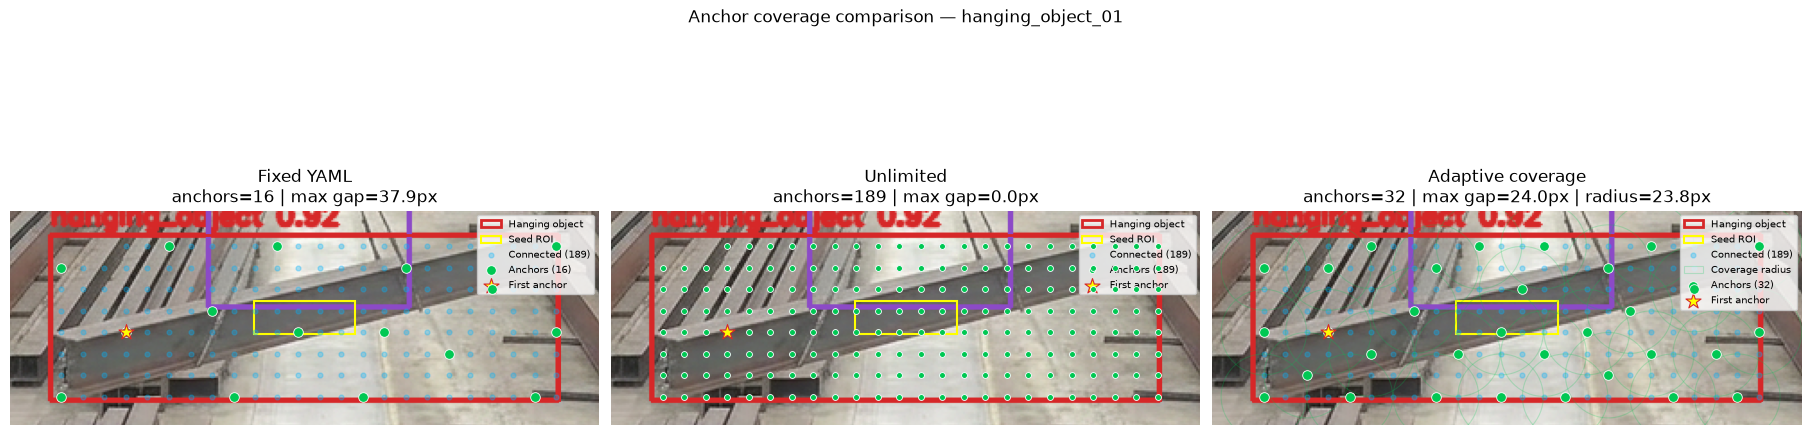

In [9]:
STRATEGY_LABELS = {
    'fixed_yaml': 'Fixed YAML',
    'unlimited': 'Unlimited',
    'adaptive_coverage': 'Adaptive coverage',
}

for item in load_geometry:
    connected = item['connected_region']
    strategy_results = item['anchor_strategy_results']
    fig, axes = plt.subplots(
        1, 3, figsize=(18, 6), constrained_layout=True,
    )
    for axis, strategy in zip(axes, STRATEGY_LABELS):
        result = strategy_results[strategy]
        anchors = result['anchors']
        coverage_radius = result['coverage_radius']
        maximum_distance = result['maximum_coverage_distance']

        axis.imshow(preview_rgb)
        add_load_regions(axis, item['detection'])
        if connected:
            axis.scatter(
                [candidate.point.x for candidate in connected],
                [candidate.point.y for candidate in connected],
                s=12, c=COLORS['accepted'], alpha=0.3,
                label=f'Connected ({len(connected)})',
            )
        if coverage_radius is not None:
            for anchor_index, anchor in enumerate(anchors):
                axis.add_patch(Circle(
                    (anchor.point.x, anchor.point.y),
                    coverage_radius, fill=False,
                    edgecolor=COLORS['selected'], linewidth=0.8, alpha=0.22,
                    label='Coverage radius' if anchor_index == 0 else None,
                ))
        if anchors:
            marker_size = 18 if len(anchors) > 32 else 48
            axis.scatter(
                [anchor.point.x for anchor in anchors],
                [anchor.point.y for anchor in anchors],
                s=marker_size, c=COLORS['selected'],
                edgecolors='white', linewidths=0.6, zorder=9,
                label=f'Anchors ({len(anchors)})',
            )
            first_anchor = anchors[0]
            axis.scatter(
                [first_anchor.point.x], [first_anchor.point.y],
                s=130, c=COLORS['seed'], marker='*',
                edgecolors=COLORS['load'], linewidths=0.8, zorder=10,
                label='First anchor',
            )
        radius_text = (
            '' if coverage_radius is None
            else f' | radius={coverage_radius:.1f}px'
        )
        axis.set_title(
            f"{STRATEGY_LABELS[strategy]}\n"
            f"anchors={len(anchors)} | max gap={maximum_distance:.1f}px"
            f"{radius_text}"
        )
        focus_on_bbox(axis, item['detection']['bbox'])
        axis.legend(loc='upper right', fontsize=7)
    fig.suptitle(f"Anchor coverage comparison — {item['object_id']}")
    plt.show()

## 5. Representative geometry

Khung vàng là centered seed ROI; kích thước lấy từ `load_inner_size_fraction`.

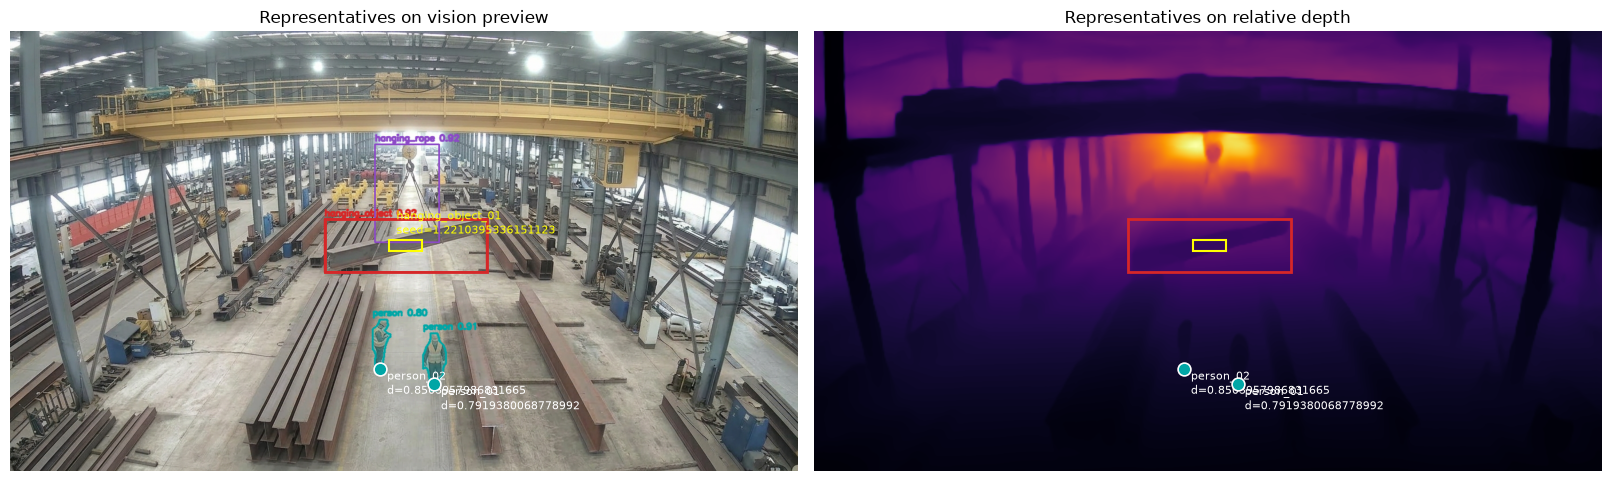

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
axes[0].imshow(preview_rgb)
axes[1].imshow(np.ma.masked_invalid(depth_map), cmap='inferno')
for item in person_geometry:
    result = item['representative']
    for axis in axes:
        axis.scatter(result.point.x, result.point.y, s=85, c=COLORS['person'],
                     edgecolors='white', linewidths=1.2, zorder=6)
        axis.annotate(f"{item['object_id']}\nd={result.depth.value}",
                      (result.point.x, result.point.y), xytext=(5, -18),
                      textcoords='offset points', color='white', fontsize=8)
for item in load_geometry:
    for axis in axes:
        add_load_regions(axis, item['detection'])
    ix1, iy1, _, _ = centered_inner_bbox(
        item['detection']['bbox'], geometry_config.representative_depth.load_inner_size_fraction,
    )
    axes[0].annotate(f"{item['object_id']}\nseed={item['candidate_selection'].seed_depth}",
                     (ix1, iy1), xytext=(5, 5), textcoords='offset points',
                     color=COLORS['seed'], fontsize=8)
axes[0].set_title('Representatives on vision preview')
axes[1].set_title('Representatives on relative depth')
for axis in axes:
    axis.axis('off')
plt.show()

## 6. Candidate generation và seed filtering

Xanh lam: `is_seed_consistent=True`. Xám: candidate có depth hợp lệ nhưng không qua seed tolerance trong `load_anchors.py`.

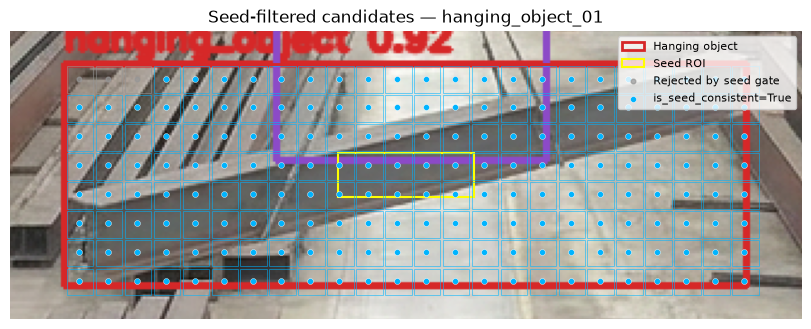

In [11]:
for item in load_geometry:
    selection = item['candidate_selection']
    accepted = list(selection.consistent_candidates)
    rejected = [c for c in selection.candidates if not c.is_seed_consistent]
    fig, axis = plt.subplots(figsize=(8, 6), constrained_layout=True)
    axis.imshow(preview_rgb)
    add_load_regions(axis, item['detection'])
    for candidate in selection.candidates:
        px1, py1, px2, py2 = candidate.patch_bbox
        color = COLORS['accepted'] if candidate.is_seed_consistent else COLORS['rejected']
        axis.add_patch(Rectangle((px1, py1), px2 - px1, py2 - py1,
                                 fill=False, edgecolor=color, linewidth=0.55, alpha=0.7))
    if rejected:
        axis.scatter([c.point.x for c in rejected], [c.point.y for c in rejected],
                     s=11, c=COLORS['rejected'], alpha=0.7, label='Rejected by seed gate')
    if accepted:
        axis.scatter([c.point.x for c in accepted], [c.point.y for c in accepted],
                     s=18, c=COLORS['accepted'], edgecolors='white', linewidths=0.3,
                     label='is_seed_consistent=True')
    focus_on_bbox(axis, item['detection']['bbox'])
    axis.set_title(f"Seed-filtered candidates — {item['object_id']}")
    axis.legend(loc='upper right', fontsize=8)
    plt.show()

## 7. Connected-region neighbor search

Connected-region chỉ nhận candidate `is_seed_consistent=True`. Candidate đỏ đã qua seed gate nhưng không nối được với root do vị trí lưới hoặc local-neighbor depth tolerance.

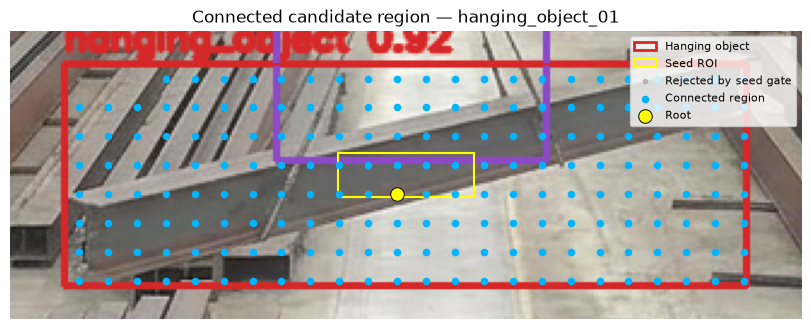

In [12]:
for item in load_geometry:
    selection = item['candidate_selection']
    connected = item['connected_region']
    connected_ids = {c.candidate_id for c in connected}
    disconnected = [c for c in selection.consistent_candidates
                    if c.candidate_id not in connected_ids]
    rejected = [c for c in selection.candidates if not c.is_seed_consistent]
    ix1, iy1, ix2, iy2 = item['inner_bbox']
    root_candidates = [
        candidate for candidate in connected
        if ix1 <= candidate.point.x < ix2 and iy1 <= candidate.point.y < iy2
    ]
    root = min(root_candidates, key=seed_sort_key) if root_candidates else None
    fig, axis = plt.subplots(figsize=(8, 6), constrained_layout=True)
    axis.imshow(preview_rgb)
    add_load_regions(axis, item['detection'])
    if rejected:
        axis.scatter([c.point.x for c in rejected], [c.point.y for c in rejected],
                     s=9, c=COLORS['rejected'], alpha=0.5, label='Rejected by seed gate')
    if connected:
        axis.scatter([c.point.x for c in connected], [c.point.y for c in connected],
                     s=20, c=COLORS['accepted'], label='Connected region')
    if disconnected:
        axis.scatter([c.point.x for c in disconnected], [c.point.y for c in disconnected],
                     s=32, c=COLORS['disconnected'], marker='x',
                     label='Seed-consistent but disconnected')
    if root is not None:
        axis.scatter(root.point.x, root.point.y, s=95, c=COLORS['seed'],
                     edgecolors='black', linewidths=0.7, zorder=8, label='Root')
    focus_on_bbox(axis, item['detection']['bbox'])
    axis.set_title(f"Connected candidate region — {item['object_id']}")
    axis.legend(loc='upper right', fontsize=8)
    plt.show()

## 8. Final load anchors

Greedy farthest-point sampling chọn các điểm có spatial coverage từ connected region. Anchor đầu tiên có `seed_depth_difference` nhỏ nhất. Mỗi anchor tiếp theo tối đa hóa khoảng cách đến anchor gần nhất đã chọn. Thuật toán dừng khi đạt `maximum_anchors` hoặc khoảng cách tốt nhất nhỏ hơn `minimum_distance`; trường hợp bằng nhau được tie-break theo `y`, `x`, rồi `candidate_id`. Kết quả giữ nguyên thứ tự greedy đã chọn. Đặt `LIMIT_FINAL_ANCHORS=True` để dùng giới hạn trong YAML; khi là `False`, notebook đặt `maximum_anchors` bằng số connected candidate và `minimum_distance=0.0` để quan sát toàn bộ thứ tự FPS.

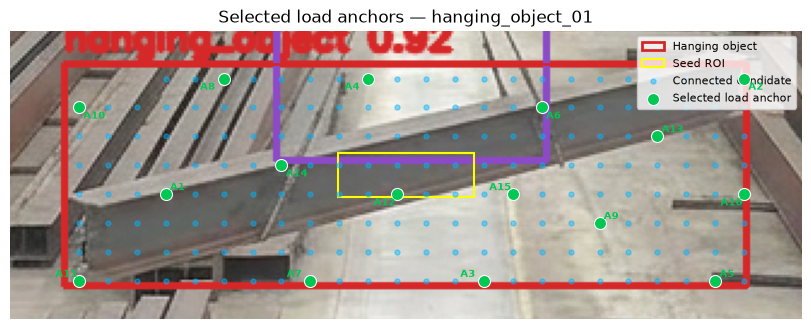

In [13]:
for item in load_geometry:
    connected = item['connected_region']
    anchors = item['load_anchors']
    fig, axis = plt.subplots(figsize=(8, 6), constrained_layout=True)
    axis.imshow(preview_rgb)
    add_load_regions(axis, item['detection'])
    if connected:
        axis.scatter([c.point.x for c in connected], [c.point.y for c in connected],
                     s=13, c=COLORS['accepted'], alpha=0.45,
                     label='Connected candidate')
    if anchors:
        axis.scatter([a.point.x for a in anchors], [a.point.y for a in anchors],
                     s=75, c=COLORS['selected'], edgecolors='white', linewidths=0.8,
                     zorder=9, label='Selected load anchor')
        offsets = [(3, 3), (3, -8), (-17, 3), (-17, -8)]
        for index, anchor in enumerate(anchors, start=1):
            axis.annotate(f'A{index}', (anchor.point.x, anchor.point.y),
                          xytext=offsets[(index - 1) % len(offsets)],
                          textcoords='offset points', color=COLORS['selected'],
                          weight='bold', fontsize=7, zorder=10)
    focus_on_bbox(axis, item['detection']['bbox'])
    axis.set_title(f"Selected load anchors — {item['object_id']}")
    axis.legend(loc='upper right', fontsize=8)
    plt.show()

## 9. Relative Pseudo-BEV projection

Project final load anchors and representative person points into a shared non-metric top-down coordinate system. The image center is lateral zero; relative depth supplies only the longitudinal coordinate, without multiplying horizontal displacement. These coordinates support comparisons within the same camera view, but they are not distances in meters.

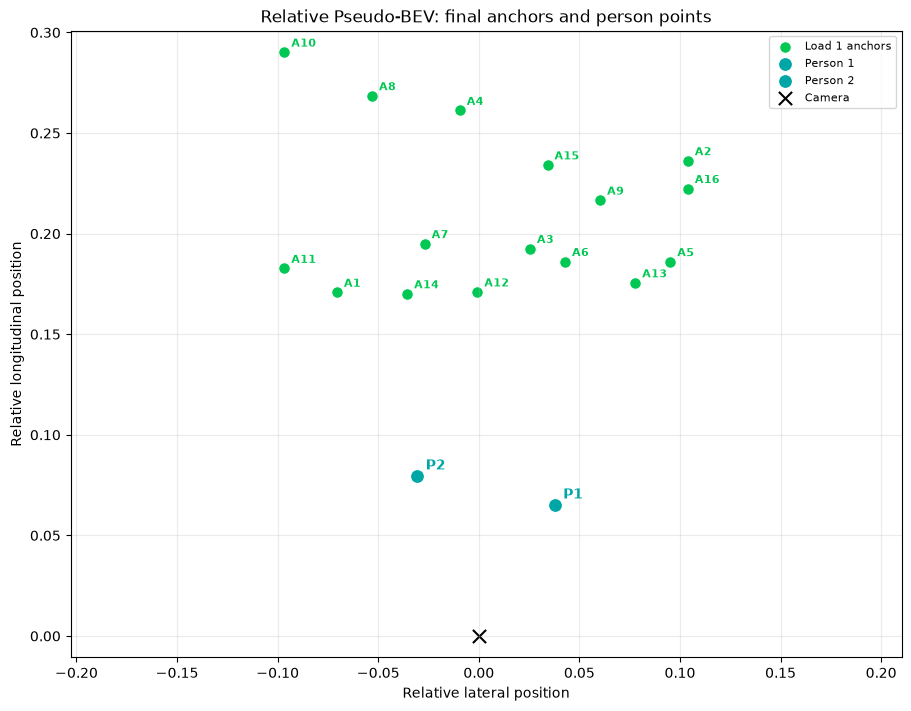

In [14]:
fig, axis = plt.subplots(figsize=(9, 7), constrained_layout=True)
for load_index, item in enumerate(load_geometry, start=1):
    points = item['pseudo_bev_points']
    if points:
        axis.scatter(
            [point.lateral for point in points],
            [point.longitudinal for point in points],
            s=70, c=COLORS['selected'], edgecolors='white', linewidths=0.8,
            label=f'Load {load_index} anchors',
        )
        for anchor_index, point in enumerate(points, start=1):
            axis.annotate(
                f'A{anchor_index}', (point.lateral, point.longitudinal),
                xytext=(5, 4), textcoords='offset points', fontsize=8,
                color=COLORS['selected'], weight='bold',
            )
for person_index, item in enumerate(person_geometry, start=1):
    point = item['pseudo_bev_point']
    if point is not None:
        axis.scatter(
            [point.lateral], [point.longitudinal],
            s=100, c=COLORS['person'], edgecolors='white', linewidths=0.8,
            label=f'Person {person_index}',
        )
        axis.annotate(
            f'P{person_index}', (point.lateral, point.longitudinal),
            xytext=(6, 5), textcoords='offset points',
            color=COLORS['person'], weight='bold',
        )
axis.scatter([0.0], [0.0], marker='x', s=90, c='black', label='Camera')
axis.set_title('Relative Pseudo-BEV: final anchors and person points')
axis.set_xlabel('Relative lateral position')
axis.set_ylabel('Relative longitudinal position')
axis.grid(alpha=0.25)
axis.set_aspect('equal', adjustable='datalim')
axis.legend(loc='best', fontsize=8)
plt.show()

## 10. Load footprint from final anchors

Build one axis-aligned footprint per load using lateral bounds from the detected object bbox and longitudinal min/max from finite final Pseudo-BEV anchors. At least two finite anchors are required.

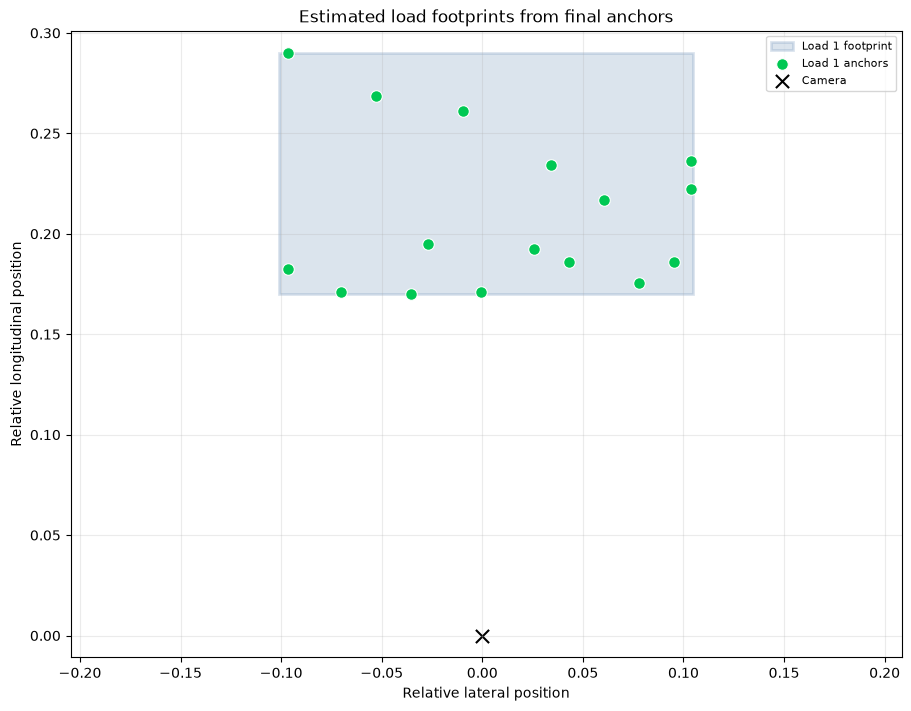

In [15]:
def add_bev_rectangle(axis, rectangle, *, color, label, alpha=0.15, linestyle='-'):
    axis.add_patch(Rectangle(
        (rectangle.minimum_lateral, rectangle.minimum_longitudinal),
        rectangle.maximum_lateral - rectangle.minimum_lateral,
        rectangle.maximum_longitudinal - rectangle.minimum_longitudinal,
        facecolor=color, edgecolor=color, linewidth=2,
        linestyle=linestyle, alpha=alpha, label=label,
    ))

fig, axis = plt.subplots(figsize=(9, 7), constrained_layout=True)
for load_index, item in enumerate(load_geometry, start=1):
    zones = item['safety_zones']
    if zones is None:
        continue
    add_bev_rectangle(
        axis, zones.footprint, color='#4C78A8',
        label=f'Load {load_index} footprint', alpha=0.20,
    )
    points = item['pseudo_bev_points']
    axis.scatter(
        [point.lateral for point in points],
        [point.longitudinal for point in points],
        s=70, c=COLORS['selected'], edgecolors='white', linewidths=0.8,
        label=f'Load {load_index} anchors', zorder=3,
    )
axis.scatter([0.0], [0.0], marker='x', s=90, c='black', label='Camera')
axis.set_title('Estimated load footprints from final anchors')
axis.set_xlabel('Relative lateral position')
axis.set_ylabel('Relative longitudinal position')
axis.grid(alpha=0.25)
axis.set_aspect('equal', adjustable='datalim')
axis.legend(loc='best', fontsize=8)
plt.show()

## 11. Danger zone and warning zone

Expand each footprint into a danger zone using per-axis half-size ratios, then expand that danger zone into a warning zone using the warning ratios.

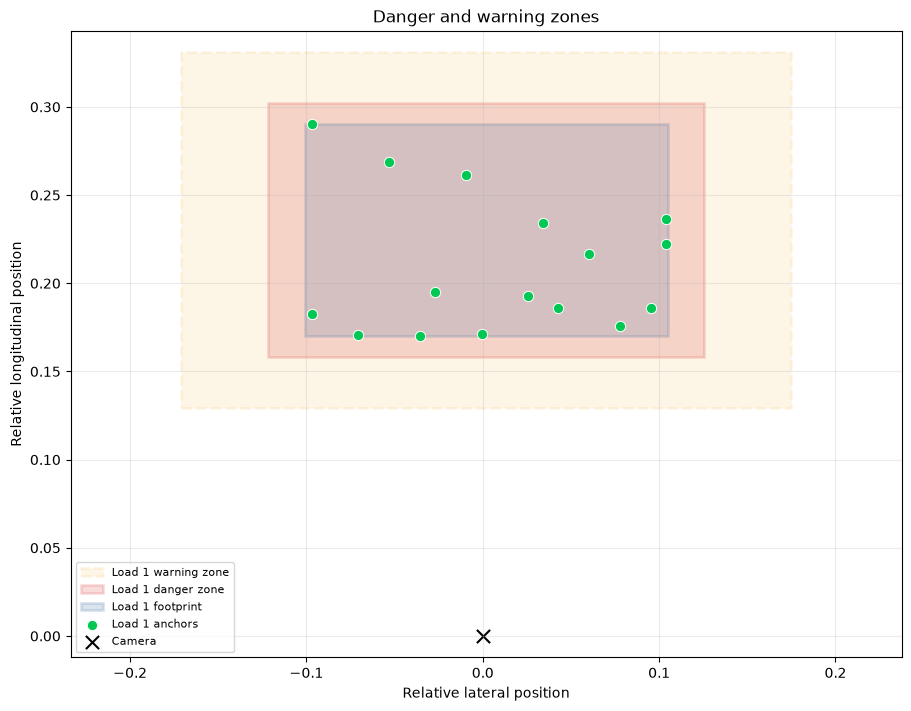

In [16]:
fig, axis = plt.subplots(figsize=(9, 7), constrained_layout=True)
for load_index, item in enumerate(load_geometry, start=1):
    zones = item['safety_zones']
    if zones is None:
        continue
    add_bev_rectangle(
        axis, zones.warning, color='#F59E0B',
        label=f'Load {load_index} warning zone', alpha=0.10, linestyle='--',
    )
    add_bev_rectangle(
        axis, zones.danger, color='#D62728',
        label=f'Load {load_index} danger zone', alpha=0.16,
    )
    add_bev_rectangle(
        axis, zones.footprint, color='#4C78A8',
        label=f'Load {load_index} footprint', alpha=0.20,
    )
    points = item['pseudo_bev_points']
    axis.scatter(
        [point.lateral for point in points],
        [point.longitudinal for point in points],
        s=55, c=COLORS['selected'], edgecolors='white', linewidths=0.7,
        label=f'Load {load_index} anchors', zorder=4,
    )
axis.scatter([0.0], [0.0], marker='x', s=90, c='black', label='Camera')
axis.set_title('Danger and warning zones')
axis.set_xlabel('Relative lateral position')
axis.set_ylabel('Relative longitudinal position')
axis.grid(alpha=0.25)
axis.set_aspect('equal', adjustable='datalim')
axis.legend(loc='best', fontsize=8)
plt.show()

## 12. Depth-independent Risk Engine

Risk engine hiện tại không nhận depth. Nó chỉ nhận anchor của person và danger/warning rectangle trong cùng một hệ tọa độ 2D. Adapter dưới đây chuyển `GeometryFrameResult` production thành các cặp `RiskPairInput`; depth vẫn dừng ở geometry pipeline và không được truyền vào `RiskEvaluator`.

Upload ảnh trả frame assessment ngay và `event=None`. Với video, cùng phương thức `process(...)` tự tạo scene event từ `upload_id` và dùng timestamp của từng frame để áp dụng confirmation frames, grace period, cooldown và exit confirmation. `track_id` từ geometry được chuyển tiếp sẵn để sau này bổ sung tracking mà không đổi evaluator.

In [17]:
def to_risk_rectangle(rectangle):
    return Rectangle2D(
        minimum_x=rectangle.minimum_lateral,
        maximum_x=rectangle.maximum_lateral,
        minimum_y=rectangle.minimum_longitudinal,
        maximum_y=rectangle.maximum_longitudinal,
    )


def geometry_to_risk_inputs(geometry_result):
    pair_inputs = []
    for person_geometry_item in geometry_result.persons:
        point = person_geometry_item.pseudo_bev_point
        for load_geometry_item in geometry_result.loads:
            zones = load_geometry_item.safety_zones
            pair_quality_reasons = tuple(dict.fromkeys(
                (*person_geometry_item.quality_reasons,
                 *load_geometry_item.quality_reasons)
            ))
            person = PersonObservation(
                person_id=person_geometry_item.person_id,
                anchor=(
                    None
                    if point is None
                    else Point2D(point.lateral, point.longitudinal)
                ),
                confidence=person_geometry_item.confidence,
                anchor_reliable=point is not None,
                mask_reliable=person_geometry_item.mask_reliable,
                quality_reasons=pair_quality_reasons,
                track_id=person_geometry_item.track_id,
            )
            pair_inputs.append(RiskPairInput(
                person=person,
                load_id=load_geometry_item.load_id,
                zones=(
                    None
                    if zones is None
                    else ZoneGeometry(
                        danger=to_risk_rectangle(zones.danger),
                        warning=to_risk_rectangle(zones.warning),
                    )
                ),
                load_track_id=load_geometry_item.track_id,
            ))
    return tuple(pair_inputs)


risk_evaluator = RiskEvaluator(risk_policy.evaluation)
risk_pipeline = RiskFramePipeline(
    evaluator=risk_evaluator,
    state_machine=EventStateMachine(risk_policy.events),
)
risk_inputs = geometry_to_risk_inputs(production_geometry_result)

risk_result = risk_pipeline.process(
    risk_inputs,
    context=MediaFrameContext(
        upload_id=IMAGE_PATH.stem,
        frame_id='frame-000000',
        frame_index=0,
        timestamp=0.0,
        media_type=MediaType.IMAGE,
    ),
)
risk_assessments = list(risk_result.assessment.pair_assessments)
risk_rows = [
    {
        'person_id': assessment.person_id,
        'person_track_id': assessment.person_track_id,
        'load_id': assessment.load_id,
        'load_track_id': assessment.load_track_id,
        'level': assessment.level.value,
        'matched_zone': (
            None
            if assessment.matched_zone is None
            else assessment.matched_zone.value
        ),
        'assessment_reliable': assessment.assessment_reliable,
        'quality_reasons': assessment.quality_reasons,
        'confidence': assessment.confidence,
    }
    for assessment in risk_assessments
]
frame_risk_summary = {
    'frame_id': risk_result.assessment.frame_id,
    'level': risk_result.assessment.level.value,
    'assessment_reliable': risk_result.assessment.assessment_reliable,
    'quality_reasons': risk_result.assessment.quality_reasons,
    'contributing_person_ids': risk_result.assessment.contributing_person_ids,
    'contributing_load_ids': risk_result.assessment.contributing_load_ids,
    'event': risk_result.event,
}
{'frame': frame_risk_summary, 'pairs': risk_rows}

{'frame': {'frame_id': 'frame-000000',
  'level': 'SAFE',
  'assessment_reliable': True,
  'quality_reasons': (),
  'contributing_person_ids': ('person_01', 'person_02'),
  'contributing_load_ids': ('hanging_object_01',),
  'event': None},
 'pairs': [{'person_id': 'person_01',
   'person_track_id': None,
   'load_id': 'hanging_object_01',
   'load_track_id': None,
   'level': 'SAFE',
   'matched_zone': None,
   'assessment_reliable': True,
   'quality_reasons': (),
   'confidence': 0.906952440738678},
  {'person_id': 'person_02',
   'person_track_id': None,
   'load_id': 'hanging_object_01',
   'load_track_id': None,
   'level': 'SAFE',
   'matched_zone': None,
   'assessment_reliable': True,
   'quality_reasons': (),
   'confidence': 0.7984516620635986}]}

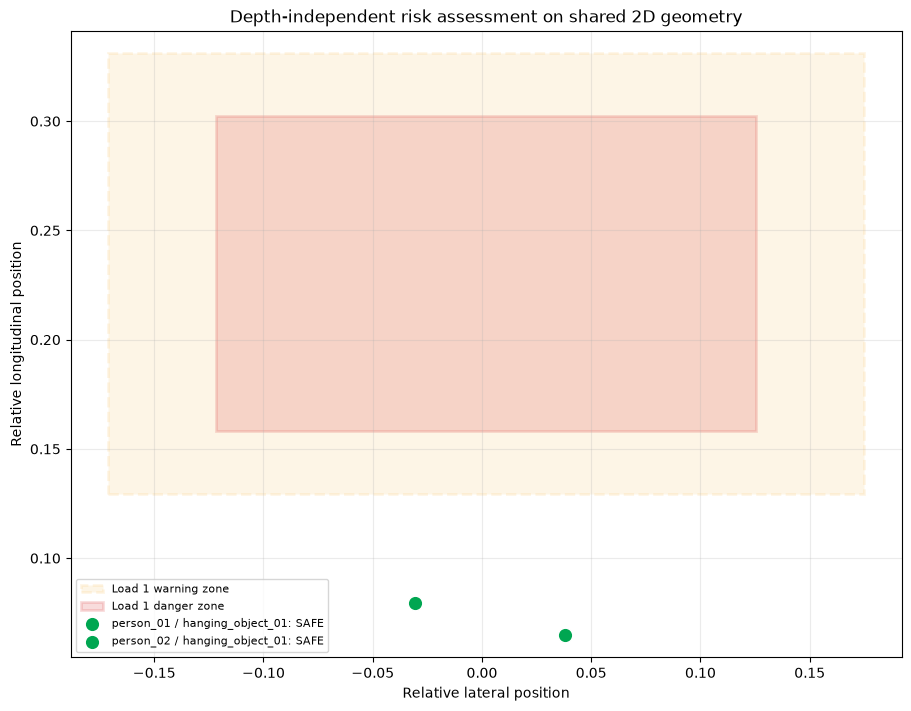

In [18]:
RISK_COLORS = {'SAFE': '#00A651', 'WARNING': '#F59E0B', 'DANGER': '#D62728'}
fig, axis = plt.subplots(figsize=(9, 7), constrained_layout=True)
for load_index, load_item in enumerate(load_geometry, start=1):
    zones = load_item['safety_zones']
    if zones is None:
        continue
    add_bev_rectangle(
        axis, zones.warning, color=RISK_COLORS['WARNING'],
        label=f'Load {load_index} warning zone', alpha=0.10, linestyle='--',
    )
    add_bev_rectangle(
        axis, zones.danger, color=RISK_COLORS['DANGER'],
        label=f'Load {load_index} danger zone', alpha=0.16,
    )
for assessment in risk_assessments:
    person_item = next(
        item for item in person_geometry
        if item['object_id'] == assessment.person_id
    )
    point = person_item['pseudo_bev_point']
    if point is None:
        continue
    axis.scatter(
        [point.lateral], [point.longitudinal], s=110,
        c=RISK_COLORS[assessment.level.value], edgecolors='white',
        linewidths=1.0, zorder=6,
        label=(
            f'{assessment.person_id} / {assessment.load_id}: '
            f'{assessment.level.value}'
        ),
    )
axis.set_title('Depth-independent risk assessment on shared 2D geometry')
axis.set_xlabel('Relative lateral position')
axis.set_ylabel('Relative longitudinal position')
axis.grid(alpha=0.25)
axis.set_aspect('equal', adjustable='datalim')
axis.legend(loc='best', fontsize=8)
plt.show()

## 13. Compact result và sanity checks

In [19]:
geometry_summary = {
    'persons': [
        {
            'object_id': item['object_id'],
            **asdict(item['representative']),
            'pseudo_bev_point': (
                None
                if item['pseudo_bev_point'] is None
                else asdict(item['pseudo_bev_point'])
            ),
        }
        for item in person_geometry
    ],
    'loads': [
        {
            'object_id': item['object_id'],
            'representative_depth': asdict(item['representative_depth']),
            'candidate_counts': next(row for row in stage_rows if row['load'] == item['object_id']),
            'anchors': [asdict(anchor) for anchor in item['load_anchors']],
            'pseudo_bev_points': [
                asdict(point) for point in item['pseudo_bev_points']
            ],
            'safety_zones': (
                None
                if item['safety_zones'] is None
                else asdict(item['safety_zones'])
            ),
        }
        for item in load_geometry
    ],
    'risk_assessments': risk_rows,
}
geometry_summary

{'persons': [{'object_id': 'person_01',
   'point': {'x': 740.0, 'y': 616.0},
   'point_source': 'segmentation_bottom_band',
   'depth': {'value': 0.7919380068778992,
    'source': 'segmentation_mask:lower',
    'quality': 'high',
    'roi_statistics': {'full': {'valid_count': 2688,
      'mean': 0.8105597496032715,
      'median': 0.8027307987213135,
      'minimum': 0.7829327583312988,
      'maximum': 0.948073148727417,
      'percentile_10': 0.7898620367050171,
      'percentile_90': 0.8452949106693268,
      'standard_deviation': 0.0245813000947237},
     'top': {'valid_count': 1894,
      'mean': 0.8172404170036316,
      'median': 0.8098462224006653,
      'minimum': 0.7894701361656189,
      'maximum': 0.948073148727417,
      'percentile_10': 0.7931905925273895,
      'percentile_90': 0.8542015492916107,
      'standard_deviation': 0.025809260085225105},
     'lower': {'valid_count': 831,
      'mean': 0.7952195405960083,
      'median': 0.7919380068778992,
      'minimum': 0.

In [20]:
assert depth_map.shape == image_bgr.shape[:2]
for item in load_geometry:
    selection = item['candidate_selection']
    connected = item['connected_region']
    anchors = item['load_anchors']
    pseudo_bev_points = item['pseudo_bev_points']
    fps_settings = item['farthest_point_sampling_settings']
    assert item['representative_depth'].value == selection.seed_depth
    assert selection.generated_patch_count >= len(selection.candidates)
    assert all(candidate.is_seed_consistent for candidate in connected)
    if connected:
        ix1, iy1, ix2, iy2 = item['inner_bbox']
        assert any(
            ix1 <= candidate.point.x < ix2 and iy1 <= candidate.point.y < iy2
            for candidate in connected
        )
    assert all(
        candidate.seed_depth_difference is not None
        and candidate.seed_depth_difference <= geometry_config.load_anchors.seed_depth_tolerance
        for candidate in connected
    )
    connected_ids = {candidate.candidate_id for candidate in connected}
    assert all(anchor.candidate_id in connected_ids for anchor in anchors)
    assert len(anchors) <= fps_settings.maximum_anchors
    assert len(pseudo_bev_points) == len(anchors)
    assert pseudo_bev_points == project_load_anchors_to_pseudo_bev(
        anchors,
        image_width=image_bgr.shape[1],
        depth_low=depth_low,
        depth_high=depth_high,
        config=geometry_config.pseudo_bev,
    )
    assert item['safety_zones'] == build_load_zones(
        pseudo_bev_points,
        load_bbox=item['detection']['bbox'],
        image_width=image_bgr.shape[1],
        pseudo_bev_config=geometry_config.pseudo_bev,
        config=geometry_config.zones,
    )
    repeated_anchors = select_farthest_load_anchors(
        connected, config=fps_settings,
    )
    assert anchors == repeated_anchors
    if anchors:
        assert anchors[0] == min(connected, key=seed_sort_key)
    for anchor_index, anchor in enumerate(anchors[1:], start=1):
        distance_to_nearest_anchor = min(
            np.hypot(
                anchor.point.x - selected_anchor.point.x,
                anchor.point.y - selected_anchor.point.y,
            )
            for selected_anchor in anchors[:anchor_index]
        )
        assert (
            distance_to_nearest_anchor
            >= fps_settings.minimum_distance
        )
if LIMIT_FINAL_ANCHORS:
    assert len(production_geometry_result.persons) == len(person_geometry)
    assert len(production_geometry_result.loads) == len(load_geometry)
    for production, notebook_item in zip(
        production_geometry_result.persons, person_geometry, strict=True,
    ):
        assert production.representative == notebook_item['representative']
        assert production.pseudo_bev_point == notebook_item['pseudo_bev_point']
    for production, notebook_item in zip(
        production_geometry_result.loads, load_geometry, strict=True,
    ):
        assert production.final_anchors == notebook_item['load_anchors']
        assert production.safety_zones == notebook_item['safety_zones']
for assessment, pair_input in zip(
    risk_assessments, risk_inputs, strict=True,
):
    assert assessment == risk_evaluator.evaluate(
        pair_input.person,
        load_id=pair_input.load_id,
        zones=pair_input.zones,
        load_track_id=pair_input.load_track_id,
    )
    assert not hasattr(assessment, 'depth')
assert risk_result.event is None
assert risk_result.assessment.frame_id == 'frame-000000'
assert risk_result.assessment.pair_assessments == tuple(risk_assessments)
print('Vision → Geometry → Risk pipeline checks passed')

Vision → Geometry → Risk pipeline checks passed
